In [1]:
pip install yfinance

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
pip install scipy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
#importarción de librerias que se utilizaran
import yfinance as yf  #Obtención de datos 
import numpy as np     #Algebra matricial 
import pandas as pd    #Manejo de series de tiempo 
import matplotlib.pyplot as plt #Visualizaciónes 
import matplotlib.cm as cm
import scipy.optimize as sco  #Optimización de indice Sharpe / Minima Varianza 
from scipy.optimize import minimize

# Configuración visual
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.style.use('seaborn-v0_8-whitegrid')

print('Perfecta Importación de librerías')

Perfecta Importación de librerías


In [4]:
#Parametros y descargo de Precios 

TICKERS = ['AAPL','IBM','MSFT','UNH','JNJ','V','AXP','BA','WMT','CAT',]
BENCHMARK = '^GSPC' #Replica el indice S&P 500
START = '2020-10-01' #Fecha de inicio 
END = '2026-04-01'   #Fecha al termino de periodo
RF = 0.0675 #Tasa libre de riesgo (CETES)

#Descarga de precios ajustados 
raw = yf.download(TICKERS + [BENCHMARK], start = START, end = END, auto_adjust=True)
precios = raw['Close']

print(f'El DataFrame: {precios}')
print(f'Peridoo: {precios.index[0].date()}, {precios.index[1].date()}')
precios.head()

[*********************100%***********************]  11 of 11 completed


El DataFrame: Ticker            AAPL         AXP          BA         CAT         IBM  \
Date                                                                     
2020-10-01  113.387589   94.354874  167.860001  132.284790   92.249237   
2020-10-02  109.727417   94.615608  168.080002  135.197174   91.853065   
2020-10-05  113.106049   96.738663  171.199997  138.398163   92.950089   
2020-10-06  109.863365   94.755295  159.539993  136.630844   92.919632   
2020-10-07  111.727417   96.263771  164.610001  139.552322   94.519463   
...                ...         ...         ...         ...         ...   
2026-03-25  252.619995  299.293823  199.610001  719.039978  241.389999   
2026-03-26  252.889999  298.446503  194.360001  703.190002  241.669998   
2026-03-27  248.800003  291.348938  190.520004  695.400024  236.339996   
2026-03-30  246.630005  296.552490  189.210007  667.429993  237.250000   
2026-03-31  253.789993  301.526764  199.029999  708.460022  242.389999   

Ticker             JNJ 

Ticker,AAPL,AXP,BA,CAT,IBM,JNJ,MSFT,UNH,V,WMT,^GSPC
Date,,,,,,,,,,,
2020-10-01,113.387589,94.354874,167.860001,132.284790,92.249237,126.259972,202.868454,285.315796,195.410263,44.306843,3380.800049
2020-10-02,109.727417,94.615608,168.080002,135.197174,91.853065,125.334404,196.881500,284.322418,193.594055,43.507912,3348.419922
2020-10-05,113.106049,96.738663,171.199997,138.398163,92.950089,127.039886,200.882370,289.945465,195.592865,43.910480,3408.600098
2020-10-06,109.863365,94.755295,159.539993,136.630844,92.919632,125.351494,196.614151,286.573456,192.623474,43.548168,3360.969971
2020-10-07,111.727417,96.263771,164.610001,139.552322,94.519463,126.739922,200.357193,294.520416,194.564636,43.628685,3419.439941


In [5]:
#Calculamos lo retornos logaritmicos  
#Seprar el benchmark de los activos de portafolio 
precios_activos = precios[TICKERS]
precios_benchmark = precios[BENCHMARK]

#Retornos logaritmicos diarios 
retornos = np.log(precios_activos / precios_activos.shift(1)).dropna() #Tenemos lag 1 y limpiamos ese retraso 
retornos_benchmark = np.log(precios_benchmark / precios_benchmark.shift(1).dropna())

# Retornos anualizados (de diario anual)
retornos_anuales = retornos.mean() * 252  #Calculamos el promedio 
volatilidad = retornos.std() * np.sqrt(252)   #Desviación estandar (std) y (raiz)

print(f'Muestra los retornos anuales de los : {retornos_anuales.round(4)}')
print(f'Muestra la volatilidad de los {volatilidad.round(4)}')



Muestra los retornos anuales de los : Ticker
AAPL    0.1472
IBM     0.1765
MSFT    0.1099
UNH    -0.0097
JNJ     0.1207
V       0.0797
AXP     0.2123
BA      0.0311
WMT     0.1885
CAT     0.3067
dtype: float64
Muestra la volatilidad de los Ticker
AAPL    0.2800
IBM     0.2552
MSFT    0.2615
UNH     0.3167
JNJ     0.1679
V       0.2289
AXP     0.3059
BA      0.3750
WMT     0.2096
CAT     0.2986
dtype: float64


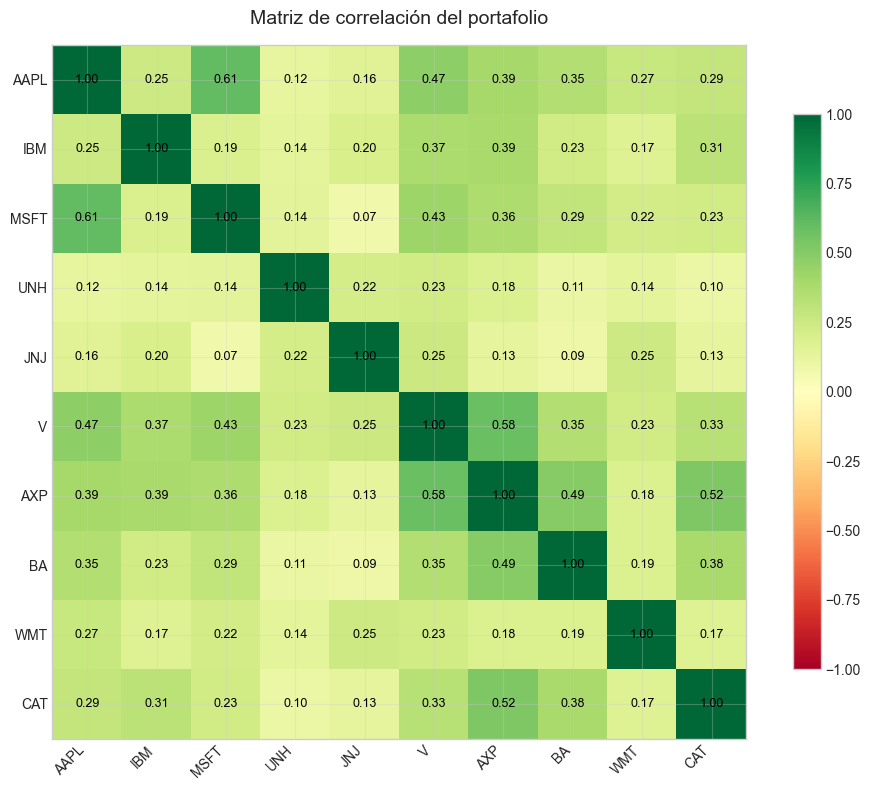


Matriz de covarianza anualizada:
Ticker    AAPL     IBM    MSFT     UNH     JNJ       V     AXP      BA  \
Ticker                                                                   
AAPL    0.0784  0.0178  0.0444  0.0111  0.0076  0.0300  0.0338  0.0365   
IBM     0.0178  0.0651  0.0130  0.0110  0.0086  0.0216  0.0302  0.0222   
MSFT    0.0444  0.0130  0.0684  0.0120  0.0032  0.0257  0.0289  0.0284   
UNH     0.0111  0.0110  0.0120  0.1003  0.0115  0.0168  0.0177  0.0126   
JNJ     0.0076  0.0086  0.0032  0.0115  0.0282  0.0096  0.0066  0.0056   
V       0.0300  0.0216  0.0257  0.0168  0.0096  0.0524  0.0409  0.0296   
AXP     0.0338  0.0302  0.0289  0.0177  0.0066  0.0409  0.0936  0.0565   
BA      0.0365  0.0222  0.0284  0.0126  0.0056  0.0296  0.0565  0.1406   
WMT     0.0159  0.0089  0.0122  0.0093  0.0087  0.0111  0.0117  0.0147   
CAT     0.0239  0.0238  0.0182  0.0092  0.0064  0.0229  0.0474  0.0430   

Ticker     WMT     CAT  
Ticker                  
AAPL    0.0159  0.0239  
IB

In [6]:
#Matriz Covarianza 
cov_matrix = retornos.cov() * 252 

#Matriz Correlación 
corr_matrix = retornos.corr() 

#visualización de Correlación 
fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(corr_matrix, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, shrink=0.8)

# Etiquetas
ax.set_xticks(range(len(TICKERS)))
ax.set_yticks(range(len(TICKERS)))
ax.set_xticklabels(TICKERS, rotation=45, ha='right')
ax.set_yticklabels(TICKERS)

# Valores dentro de cada celda
for i in range(len(TICKERS)):
    for j in range(len(TICKERS)):
        ax.text(j, i, f'{corr_matrix.iloc[i,j]:.2f}',
                ha='center', va='center', fontsize=9,
                color='black')

ax.set_title('Matriz de correlación del portafolio', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

print("\nMatriz de covarianza anualizada:")
print(cov_matrix.round(4))

In [7]:
def portafolio_return(weights, returns):
    "Retorno esperado de portafolio" #Formula
    return np.dot(weights, returns)

def portafolio_votalilidad(weights, cov_matrix):
    "Volatilidad anual del portafolio" #Formula
    return np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))

def sharpe_ratio(weights,returns,cov_matrix, rf= RF):
    "Indice de Sharpe"
    r = portafolio_return(weights, returns)
    v = portafolio_votalilidad(weights, cov_matrix)
    return -(r-rf) / v 

mu = retornos_anuales.values
cov = cov_matrix.values
n = len(TICKERS)

w_iguales = np.ones(n) / n 

print(f"Retorno portafolio equitativo:     {portafolio_return(w_iguales, mu):.4f}")
print(f"Volatilidad portafolio equitativo: {portafolio_votalilidad(w_iguales, cov):.4f}")
print(f"Sharpe portafolio equitativo:      {-sharpe_ratio(w_iguales, mu, cov):.4f}")

Retorno portafolio equitativo:     0.1363
Volatilidad portafolio equitativo: 0.1595
Sharpe portafolio equitativo:      0.4314


Simulaciones completadas: 5,000
Mejor Sharpe encontrado:  0.7494
Retorno del mejor:        0.1934
Volatilidad del mejor:    0.1680


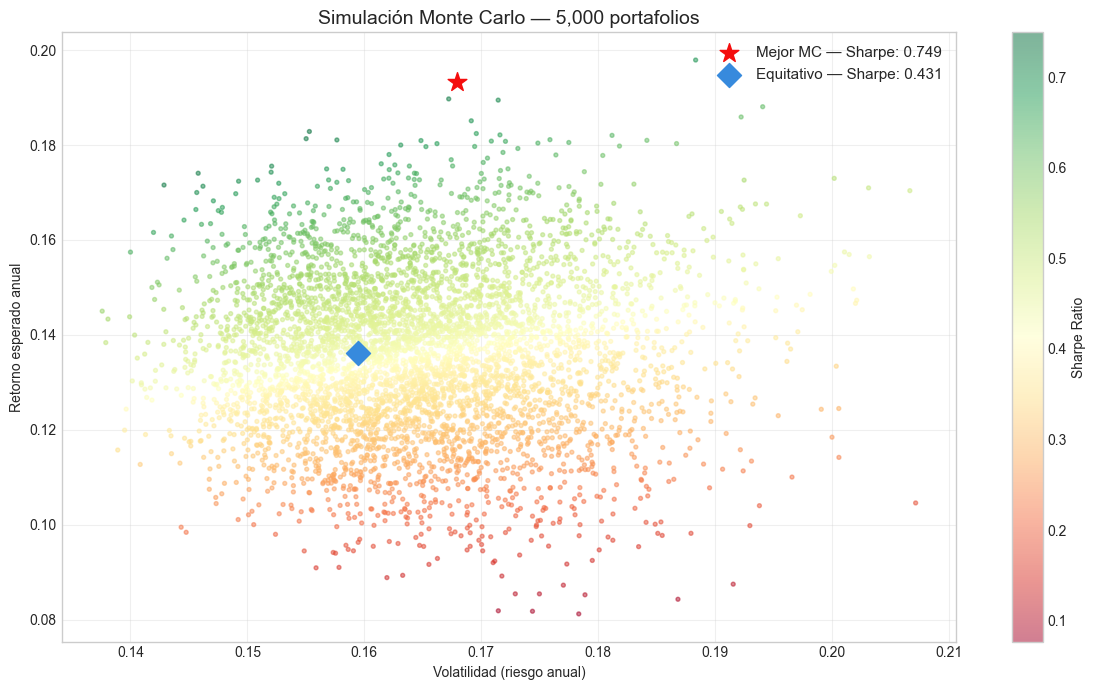

In [8]:
# ── Celda 6: Simulación Monte Carlo ─────────────────────────────

np.random.seed(42)          # reproducibilidad — mismo resultado cada vez
N_SIMULACIONES = 5000

# Arrays para guardar resultados
mc_retornos     = np.zeros(N_SIMULACIONES)
mc_volatilidades = np.zeros(N_SIMULACIONES)
mc_sharpes      = np.zeros(N_SIMULACIONES)
mc_pesos        = np.zeros((N_SIMULACIONES, n))

for i in range(N_SIMULACIONES):
    # 1. Generar pesos aleatorios que sumen 100%
    w = np.random.random(n)
    w = w / w.sum()

    # 2. Calcular métricas del portafolio
    mc_retornos[i]      = portafolio_return(w, mu)
    mc_volatilidades[i] = portafolio_votalilidad(w, cov)
    mc_sharpes[i]       = -sharpe_ratio(w, mu, cov)
    mc_pesos[i]         = w

print(f"Simulaciones completadas: {N_SIMULACIONES:,}")
print(f"Mejor Sharpe encontrado:  {mc_sharpes.max():.4f}")
print(f"Retorno del mejor:        {mc_retornos[mc_sharpes.argmax()]:.4f}")
print(f"Volatilidad del mejor:    {mc_volatilidades[mc_sharpes.argmax()]:.4f}")

# ── Visualización ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))

scatter = ax.scatter(
    mc_volatilidades,
    mc_retornos,
    c=mc_sharpes,
    cmap='RdYlGn',
    alpha=0.5,
    s=8
)
plt.colorbar(scatter, ax=ax, label='Sharpe Ratio')

# Marcar el mejor portafolio Monte Carlo
idx_mejor = mc_sharpes.argmax()
ax.scatter(mc_volatilidades[idx_mejor], mc_retornos[idx_mejor],
        color="#F40D0D", s=200, zorder=5, marker='*',
        label=f'Mejor MC — Sharpe: {mc_sharpes[idx_mejor]:.3f}')

# Marcar portafolio equitativo
ax.scatter(portafolio_votalilidad(w_iguales, cov),
        portafolio_return(w_iguales, mu),
        color='#378ADD', s=150, zorder=5, marker='D',
        label=f'Equitativo — Sharpe: {-sharpe_ratio(w_iguales,mu,cov):.3f}')

ax.set_xlabel('Volatilidad (riesgo anual)')
ax.set_ylabel('Retorno esperado anual')
ax.set_title('Simulación Monte Carlo — 5,000 portafolios', fontsize=14)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

In [9]:
# ── Celda 7: Optimización numérica ──────────────────────────────

# ── Restricciones y límites ──────────────────────────────────────
restricciones = [
    {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}  # pesos suman 100%
]

limites = tuple((0, 1) for _ in range(n))            # 0% ≤ wi ≤ 100%

w0 = np.ones(n) / n                                  # punto de partida

# ── Portafolio 1: Máximo Sharpe (portafolio tangente) ────────────
opt_sharpe = minimize(
    sharpe_ratio,
    w0,
    args=(mu, cov),
    method='SLSQP',
    bounds=limites,
    constraints=restricciones
)

w_sharpe = opt_sharpe.x
ret_sharpe  = portafolio_return(w_sharpe, mu)
vol_sharpe  = portafolio_votalilidad(w_sharpe, cov)
sr_sharpe   = -sharpe_ratio(w_sharpe, mu, cov)

# ── Portafolio 2: Mínima varianza ────────────────────────────────
opt_minvar = minimize(
    portafolio_votalilidad,
    w0,
    args=(cov,),
    method='SLSQP',
    bounds=limites,
    constraints=restricciones
)

w_minvar = opt_minvar.x
ret_minvar = portafolio_return(w_minvar, mu)
vol_minvar = portafolio_votalilidad(w_minvar, cov)
sr_minvar  = -sharpe_ratio(w_minvar, mu, cov)

# ── Resultados ───────────────────────────────────────────────────
print("=" * 52)
print(f"{'PORTAFOLIO MÁXIMO SHARPE':^52}")
print("=" * 52)
for ticker, w in zip(TICKERS, w_sharpe):
    if w > 0.001:
        print(f"  {ticker:<6} {w*100:>8.2f}%")
print(f"\n  Retorno esperado : {ret_sharpe*100:.2f}%")
print(f"  Volatilidad      : {vol_sharpe*100:.2f}%")
print(f"  Sharpe ratio     : {sr_sharpe:.4f}")

print("\n" + "=" * 52)
print(f"{'PORTAFOLIO MÍNIMA VARIANZA':^52}")
print("=" * 52)
for ticker, w in zip(TICKERS, w_minvar):
    if w > 0.001:
        print(f"  {ticker:<6} {w*100:>8.2f}%")
print(f"\n  Retorno esperado : {ret_minvar*100:.2f}%")
print(f"  Volatilidad      : {vol_minvar*100:.2f}%")
print(f"  Sharpe ratio     : {sr_minvar:.4f}")

              PORTAFOLIO MÁXIMO SHARPE              
  IBM        9.21%
  JNJ       11.35%
  WMT       37.01%
  CAT       42.43%

  Retorno esperado : 22.98%
  Volatilidad      : 17.42%
  Sharpe ratio     : 0.9317

             PORTAFOLIO MÍNIMA VARIANZA             
  IBM        9.42%
  MSFT      12.03%
  UNH        5.77%
  JNJ       42.10%
  V          4.77%
  BA         0.65%
  WMT       19.45%
  CAT        5.81%

  Retorno esperado : 13.86%
  Volatilidad      : 12.76%
  Sharpe ratio     : 0.5570


C:\Users\Axel\AppData\Local\Temp\ipykernel_18624\1748393723.py:78: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  xy=(volatilidad[i], mu[i]),


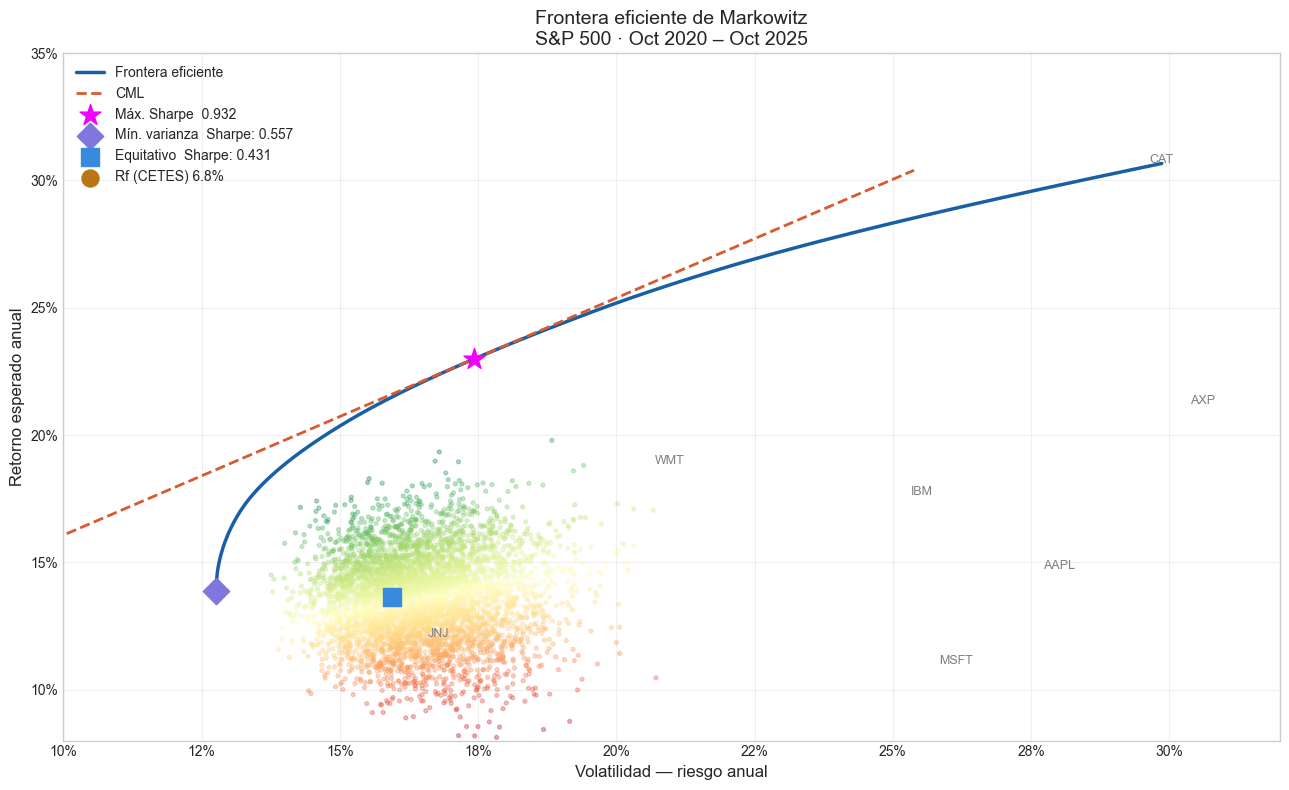

In [10]:
# ── Celda 8: Frontera eficiente completa ────────────────────────

def frontera_eficiente(mu, cov, n_puntos=500):
    """
    Genera la frontera eficiente calculando el portafolio de
    mínima varianza para cada nivel de retorno objetivo.
    """
    retornos_objetivo = np.linspace(ret_minvar, mu.max(), n_puntos)
    volatilidades_fe  = []

    for ret_obj in retornos_objetivo:
        restricciones_fe = [
            {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
            {'type': 'eq', 'fun': lambda w, r=ret_obj:
                portafolio_return(w, mu) - r}
        ]
        resultado = minimize(
            portafolio_votalilidad,
            w0,
            args=(cov,),
            method='SLSQP',
            bounds=limites,
            constraints=restricciones_fe
        )
        volatilidades_fe.append(resultado.fun)

    return retornos_objetivo, np.array(volatilidades_fe)

# Calcular frontera
ret_fe, vol_fe = frontera_eficiente(mu, cov)

# ── Línea del Mercado de Capitales (CML) ─────────────────────────
vol_cml = np.linspace(0, vol_fe.max() * 0.85, 200)
ret_cml = RF + (ret_sharpe - RF) / vol_sharpe * vol_cml

# ── Visualización completa ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 8))

# Nube Monte Carlo
ax.scatter(mc_volatilidades, mc_retornos,
        c=mc_sharpes, cmap='RdYlGn',
        alpha=0.3, s=8, zorder=1)

# Frontera eficiente
ax.plot(vol_fe, ret_fe,
        color='#185FA5', linewidth=2.5,
        label='Frontera eficiente', zorder=3)

# CML
ax.plot(vol_cml, ret_cml,
        color='#D85A30', linewidth=2,
        linestyle='--', label='CML', zorder=3)

ax.set_xlim(0.10, 0.32)
ax.set_ylim(0.08, 0.35)

# Puntos especiales
ax.scatter(vol_sharpe, ret_sharpe,
        color="#F200FF", s=250, zorder=5,
        marker='*', label=f'Máx. Sharpe  {sr_sharpe:.3f}')

ax.scatter(vol_minvar, ret_minvar,
        color='#7F77DD', s=180, zorder=5,
        marker='D', label=f'Mín. varianza  Sharpe: {sr_minvar:.3f}')

ax.scatter(portafolio_votalilidad(w_iguales, cov),
        portafolio_return(w_iguales, mu),
        color='#378ADD', s=180, zorder=5,
        marker='s', label=f'Equitativo  Sharpe: {-sharpe_ratio(w_iguales,mu,cov):.3f}')

# Rf
ax.scatter(0, RF, color='#BA7517', s=150,
        zorder=5, marker='o', label=f'Rf (CETES) {RF*100:.1f}%')

# Etiquetas de activos individuales
for i, ticker in enumerate(TICKERS):
    ax.annotate(ticker,
                xy=(volatilidad[i], mu[i]),
                fontsize=9,
                color='gray',
                ha='center')

ax.set_xlabel('Volatilidad — riesgo anual', fontsize=12)
ax.set_ylabel('Retorno esperado anual', fontsize=12)
ax.set_title('Frontera eficiente de Markowitz\n'
            'S&P 500 · Oct 2020 – Oct 2025', fontsize=14)
ax.legend(fontsize=10, loc='upper left')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x*100:.0f}%'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x*100:.0f}%'))

plt.tight_layout()
plt.show()

In [11]:
# ── Celda 9: Métricas de riesgo ──────────────────────────────────

from scipy import stats

# Retornos diarios del portafolio óptimo
retornos_portafolio = retornos.dot(w_sharpe)

# Capital inicial — puedes cambiarlo
CAPITAL = 1_000_000  # 1 millón de pesos

# ── VaR Paramétrico ──────────────────────────────────────────────
confianza_95 = 0.95
confianza_99 = 0.99

VaR_95 = CAPITAL * (retornos_portafolio.mean() - 
          stats.norm.ppf(confianza_95) * retornos_portafolio.std())

VaR_99 = CAPITAL * (retornos_portafolio.mean() - 
          stats.norm.ppf(confianza_99) * retornos_portafolio.std())

# ── VaR Histórico ────────────────────────────────────────────────
VaR_hist_95 = CAPITAL * np.percentile(retornos_portafolio, 5)
VaR_hist_99 = CAPITAL * np.percentile(retornos_portafolio, 1)

# ── CVaR (Expected Shortfall) ────────────────────────────────────
CVaR_95 = CAPITAL * retornos_portafolio[
        retornos_portafolio <= np.percentile(retornos_portafolio, 5)].mean()

CVaR_99 = CAPITAL * retornos_portafolio[
        retornos_portafolio <= np.percentile(retornos_portafolio, 1)].mean()

# ── Sortino Ratio ────────────────────────────────────────────────
retornos_negativos = retornos_portafolio[retornos_portafolio < 0]
downside_deviation = np.sqrt(252) * retornos_negativos.std()
sortino = (ret_sharpe - RF) / downside_deviation

# ── Máximo Drawdown ──────────────────────────────────────────────
valor_acumulado = (1 + retornos_portafolio).cumprod()
maximo_acumulado = valor_acumulado.cummax()
drawdown = (valor_acumulado - maximo_acumulado) / maximo_acumulado
max_drawdown = drawdown.min()

# ── Resultados ───────────────────────────────────────────────────
print("=" * 52)
print(f"{'MÉTRICAS DE RIESGO — PORTAFOLIO ÓPTIMO':^52}")
print(f"{'Capital: ${CAPITAL:,.0f}':^52}")
print("=" * 52)

print(f"\n── VaR Paramétrico (1 día) ──")
print(f"  VaR 95%:  ${VaR_95:>12,.0f}")
print(f"  VaR 99%:  ${VaR_99:>12,.0f}")

print(f"\n── VaR Histórico (1 día) ────")
print(f"  VaR 95%:  ${VaR_hist_95:>12,.0f}")
print(f"  VaR 99%:  ${VaR_hist_99:>12,.0f}")

print(f"\n── CVaR / Expected Shortfall ─")
print(f"  CVaR 95%: ${CVaR_95:>12,.0f}")
print(f"  CVaR 99%: ${CVaR_99:>12,.0f}")

print(f"\n── Métricas de desempeño ────")
print(f"  Sharpe ratio:    {sr_sharpe:.4f}")
print(f"  Sortino ratio:   {sortino:.4f}")
print(f"  Máx. Drawdown:   {max_drawdown*100:.2f}%")

       MÉTRICAS DE RIESGO — PORTAFOLIO ÓPTIMO       
              Capital: ${CAPITAL:,.0f}              

── VaR Paramétrico (1 día) ──
  VaR 95%:  $     -17,140
  VaR 99%:  $     -24,620

── VaR Histórico (1 día) ────
  VaR 95%:  $     -16,051
  VaR 99%:  $     -28,351

── CVaR / Expected Shortfall ─
  CVaR 95%: $     -23,732
  CVaR 99%: $     -36,083

── Métricas de desempeño ────
  Sharpe ratio:    0.9317
  Sortino ratio:   1.3858
  Máx. Drawdown:   -22.69%
